In [1]:
import numpy as np
import matplotlib as mpl
mpl.rcParams['font.size'] = 14
import matplotlib.pyplot as plt

from wisp.core import (
    run_timestepping,
)
from wisp.diagnostics import (
    compute_gamma,
    plot_initial_velocity_distribution,
    plot_full_f_velocity_distribution,
)

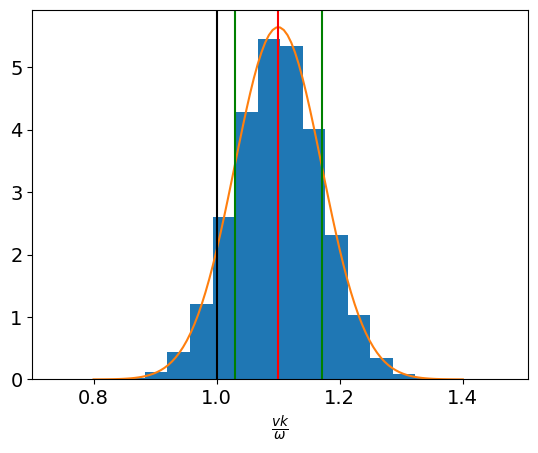

In [2]:
sim_params = {
    "E_c": 1e-12,  # initial E_c (cosine component)
    "E_s": -1e-12,  # initial E_s (sine component)
    "nb_over_ne": 5e-5,  # coupling constant
    "n_steps": 5000,  # number of timesteps
    "dt": 0.1,  # timestep (normalized by wave period)
    "n_particles": 5000000,  # number of particles
    "vb": 0.1,  # beam thermal velocity over wave phase velocity
    "ub": 1.1,  # beam flow velocity over wave phase velocity
    "splitting_method": "strang",  # 'strang' or 'trotter'
    "method": "nonlinear",  # 'linear' or 'nonlinear'
    "full_f": True,  # whether to use full distribution function (only for nonlinear)
}

fig, ax = plot_initial_velocity_distribution(sim_params)


In [3]:
sim_outputs = run_timestepping(sim_params)

E_c = sim_outputs["E_c"]
E_s = sim_outputs["E_s"]
x = sim_outputs["x"]
v = sim_outputs["v"]
w = sim_outputs["w"]

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


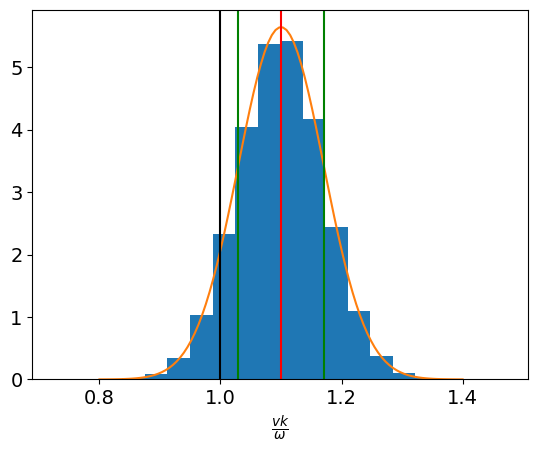

In [4]:

fig, ax = plot_full_f_velocity_distribution(v, sim_params["ub"], sim_params["vb"])

E_c_hist = sim_outputs["E_c_hist"]
E_s_hist = sim_outputs["E_s_hist"]
E_amp_hist = sim_outputs["E_amp_hist"]
phi_hist = sim_outputs["phi_hist"]
time = sim_outputs["time"]

In [5]:
gamma = compute_gamma(sim_params)

print('Predicted linear growth rate: ', gamma)
print('Predicted nonlinear saturated amplitude: ', gamma * gamma * (3.2 * 3.2))

Predicted linear growth rate:  0.003260246660866457
Predicted nonlinear saturated amplitude:  0.00010884309288643467


Text(0, 0.5, '$\\hat{E}$')

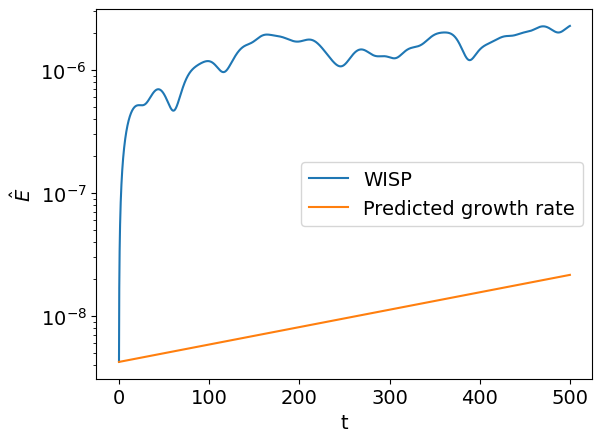

In [6]:
plt.figure()
plt.semilogy(time, np.abs(E_amp_hist), label='WISP')
plt.semilogy(time, np.abs(E_amp_hist[0])*np.exp(gamma*time), label='Predicted growth rate')
plt.legend()
plt.xlabel('t')
plt.ylabel(r'$\hat{E}$')